an example of multiverse analysis: is bill depth/length associated with body size in penguins?

In [3]:
# Load from package data (fast, no download)
from bettercode.penguindata import load_penguin_data, load_all_species
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

from bettercode.utils import save_fig

IMAGE_DIR = Path('../../latex/figures')
CHAPTER = 9

all_penguins = load_all_species()
all_penguins = all_penguins.dropna(subset=['Body_Mass', 'Sex'])

# create year column from Date
all_penguins['Year'] = all_penguins['Date_Egg'].dt.year

print(all_penguins.shape)
all_penguins.Species.value_counts()


(333, 19)


Species
Adelie Penguin (Pygoscelis adeliae)          146
Gentoo penguin (Pygoscelis papua)            119
Chinstrap penguin (Pygoscelis antarctica)     68
Name: count, dtype: int64

### Multiverse dimensions:

- how to model species
    - not modeled
    - random intercept
    - random slope
- covariate adjustments
    - sex
    - island
    - year
    - body mass

Let's develop a dataclass that can store the model representation

In [4]:
from dataclasses import dataclass, field
from typing import List, Optional, Literal
import pandas as pd
import numpy as np
from statsmodels.regression.mixed_linear_model import MixedLM
import statsmodels.formula.api as smf
import warnings


@dataclass
class ModelSpec:
    """
    Specification for a penguin bill depth/length model in the multiverse.
    
    Attributes:
        species_model: How to model species effects
            - 'none': Don't model species
            - 'random_intercept': Random intercept by species
            - 'random_slope': Random intercept and slope by species
        covariates: List of covariates to include
            Options: 'sex', 'island', 'year', 'body_mass'
        model_id: Optional unique identifier for this model specification
    """
    species_model: Literal['none', 'random_intercept', 'random_slope']
    covariates: List[str] = field(default_factory=list)
    model_id: Optional[str] = None
    
    def __post_init__(self):
        """Validate inputs and generate model_id if not provided."""
        valid_covariates = {'sex', 'island', 'year', 'body_mass'}
        invalid = set(self.covariates) - valid_covariates
        if invalid:
            raise ValueError(f"Invalid covariates: {invalid}. Must be from {valid_covariates}")
        
        if self.model_id is None:
            # Generate a unique ID based on specifications
            covs = '_'.join(sorted(self.covariates)) if self.covariates else 'none'
            self.model_id = f"{self.species_model}_{covs}"
    
    def build_formula(self) -> str:
        """
        Build the regression formula for this model specification.
        
        Returns:
            Formula string for statsmodels
        """
        # Dependent variable: bill depth, independent: bill length
        formula_parts = ['Culmen_Depth ~ Culmen_Length']
        
        # Add covariates
        if 'sex' in self.covariates:
            formula_parts.append('C(Sex)')
        if 'island' in self.covariates:
            formula_parts.append('C(Island)')
        if 'year' in self.covariates:
            formula_parts.append('C(Year)')
        if 'body_mass' in self.covariates:
            formula_parts.append('Body_Mass')
        
        return ' + '.join(formula_parts)
    
    def fit(self, data: pd.DataFrame) -> dict:
        """
        Fit the model to the penguin data.
        
        Args:
            data: DataFrame with penguin measurements
            
        Returns:
            Dictionary with model results including:
                - coefficient: effect of bill length on bill depth
                - std_err: standard error of the coefficient
                - p_value: p-value for the coefficient
                - ci_lower: lower 95% confidence interval
                - ci_upper: upper 95% confidence interval
                - n_obs: number of observations
                - r_squared: R-squared (or pseudo R-squared for mixed models)
                - aic: Akaike Information Criterion
                - converged: whether the model converged (for mixed models)
                - n_iterations: number of iterations (for mixed models)
                - optimizer_used: which optimizer was used (for mixed models)
                - model_spec: this ModelSpec object
        """
        # Prepare data - remove rows with missing values in relevant columns
        required_cols = ['Culmen_Depth', 'Culmen_Length']
        if 'sex' in self.covariates:
            required_cols.append('Sex')
        if 'island' in self.covariates:
            required_cols.append('Island')
        if 'year' in self.covariates:
            required_cols.append('Year')
        if 'body_mass' in self.covariates:
            required_cols.append('Body_Mass')
        if self.species_model != 'none':
            required_cols.append('Species')
        
        df = data[required_cols].dropna()
        
        # Build formula
        formula = self.build_formula()
        
        # Initialize convergence info (None for OLS models)
        converged = None
        n_iterations = None
        optimizer_used = None
        
        # Fit the appropriate model
        if self.species_model == 'none':
            # Simple linear regression
            model = smf.ols(formula, data=df)
            result = model.fit()
            r_squared = result.rsquared
            
        elif self.species_model == 'random_intercept':
            # Mixed model with random intercept
            model = MixedLM.from_formula(formula, data=df, groups=df['Species'])
            result = model.fit(reml=True, maxiter=200)
            r_squared = None  # Mixed models don't have simple R-squared
            # Get convergence information
            converged = result.converged
            optimizer_used = 'lbfgs'
            n_iterations = result.k_fe  # Number of fixed effects iterations
            if hasattr(result, 'n_iter'):
                n_iterations = result.n_iter
            
        else:  # random_slope
            # Mixed model with random intercept and slope
            # Try multiple strategies for better convergence
            model = MixedLM.from_formula(
                formula, 
                data=df, 
                groups=df['Species'],
                re_formula='~Culmen_Length'
            )
            
            result = None
            
            # Strategy 1: Try with BFGS optimizer and increased iterations
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                try:
                    result = model.fit(method='bfgs', reml=True, maxiter=500, 
                                      gtol=1e-4, ftol=1e-4)
                    optimizer_used = 'bfgs'
                    # If didn't converge, try next strategy
                    if not result.converged:
                        result = None
                except:
                    result = None
            
            # Strategy 2: Try Powell optimizer if BFGS didn't converge
            if result is None or not result.converged:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    try:
                        result = model.fit(method='powell', reml=True, maxiter=500)
                        optimizer_used = 'powell'
                        if not result.converged:
                            result = None
                    except:
                        result = None
            
            # Strategy 3: Try CG (Conjugate Gradient) method
            if result is None or not result.converged:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    try:
                        result = model.fit(method='cg', reml=True, maxiter=500)
                        optimizer_used = 'cg'
                        if not result.converged:
                            result = None
                    except:
                        result = None
            
            # Strategy 4: Fall back to default L-BFGS with very relaxed tolerances
            if result is None or not result.converged:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    result = model.fit(reml=True, maxiter=1000, 
                                      gtol=1e-3, ftol=1e-3)
                    optimizer_used = 'lbfgs_relaxed'
            
            r_squared = None
            # Get convergence information
            converged = result.converged
            n_iterations = result.k_fe
            if hasattr(result, 'n_iter'):
                n_iterations = result.n_iter
        
        # Extract coefficient for Culmen_Length
        coef_name = 'Culmen_Length'
        coef = result.params[coef_name]
        std_err = result.bse[coef_name]
        p_value = result.pvalues[coef_name]
        
        # Get confidence interval
        ci = result.conf_int().loc[coef_name]
        
        return {
            'model_id': self.model_id,
            'coefficient': coef,
            'std_err': std_err,
            'p_value': p_value,
            'ci_lower': ci[0],
            'ci_upper': ci[1],
            'n_obs': int(result.nobs),
            'r_squared': r_squared,
            'aic': result.aic,
            'converged': converged,
            'n_iterations': n_iterations,
            'optimizer_used': optimizer_used,
            'species_model': self.species_model,
            'covariates': ','.join(sorted(self.covariates)) if self.covariates else 'none',
            'formula': formula,
        }
    
    def __repr__(self):
        """String representation of the model specification."""
        covs = ', '.join(self.covariates) if self.covariates else 'none'
        return f"ModelSpec(species={self.species_model}, covariates=[{covs}], id={self.model_id})"


# Example usage
spec = ModelSpec(species_model='random_intercept', covariates=['sex', 'body_mass'])
print(spec)
print(f"Formula: {spec.build_formula()}")

ModelSpec(species=random_intercept, covariates=[sex, body_mass], id=random_intercept_body_mass_sex)
Formula: Culmen_Depth ~ Culmen_Length + C(Sex) + Body_Mass


### Test fitting a single model

In [5]:
# Test a single model
test_spec = ModelSpec(species_model='random_slope', covariates=['sex', 'body_mass'])
results = test_spec.fit(all_penguins)

print("Model Results:")
for key, value in results.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

Model Results:
  model_id: random_slope_body_mass_sex
  coefficient: 0.0489
  std_err: 0.0249
  p_value: 0.0495
  ci_lower: 0.0001
  ci_upper: 0.0976
  n_obs: 333
  r_squared: None
  aic: nan
  converged: True
  n_iterations: 4
  optimizer_used: powell
  species_model: random_slope
  covariates: body_mass,sex
  formula: Culmen_Depth ~ Culmen_Length + C(Sex) + Body_Mass


### Generate the full multiverse

Now let's create all possible combinations of our multiverse dimensions and fit all models.

In [6]:
from itertools import combinations, product

# Define multiverse dimensions
species_models = ['none', 'random_intercept', 'random_slope']
covariate_options = ['sex', 'island', 'year', 'body_mass']

# Generate all possible covariate combinations (including empty set)
all_covariate_combos = [[]]  # Start with no covariates
for r in range(1, len(covariate_options) + 1):
    all_covariate_combos.extend([list(combo) for combo in combinations(covariate_options, r)])

# Create all model specifications
all_specs = []
for species_model in species_models:
    for covariates in all_covariate_combos:
        spec = ModelSpec(species_model=species_model, covariates=covariates)
        all_specs.append(spec)

print(f"Total number of models in the multiverse: {len(all_specs)}")
print(f"\nFirst 10 model specifications:")
for spec in all_specs[:10]:
    print(f"  {spec}")

Total number of models in the multiverse: 48

First 10 model specifications:
  ModelSpec(species=none, covariates=[none], id=none_none)
  ModelSpec(species=none, covariates=[sex], id=none_sex)
  ModelSpec(species=none, covariates=[island], id=none_island)
  ModelSpec(species=none, covariates=[year], id=none_year)
  ModelSpec(species=none, covariates=[body_mass], id=none_body_mass)
  ModelSpec(species=none, covariates=[sex, island], id=none_island_sex)
  ModelSpec(species=none, covariates=[sex, year], id=none_sex_year)
  ModelSpec(species=none, covariates=[sex, body_mass], id=none_body_mass_sex)
  ModelSpec(species=none, covariates=[island, year], id=none_island_year)
  ModelSpec(species=none, covariates=[island, body_mass], id=none_body_mass_island)


In [7]:
# Fit all models in the multiverse
from tqdm import tqdm

multiverse_results = []

for spec in tqdm(all_specs, desc="Fitting models"):
    try:
        result = spec.fit(all_penguins)
        multiverse_results.append(result)
    except Exception as e:
        print(f"Error fitting {spec.model_id}: {e}")
        continue

# Convert to DataFrame
results_df = pd.DataFrame(multiverse_results)
print(f"\nSuccessfully fit {len(results_df)} models")
print(f"\nSummary statistics for bill length coefficient:")
print(results_df['coefficient'].describe())

Fitting models:   0%|          | 0/48 [00:00<?, ?it/s]

Fitting models: 100%|██████████| 48/48 [00:01<00:00, 41.11it/s] 


Successfully fit 48 models

Summary statistics for bill length coefficient:
count    48.000000
mean      0.051968
std       0.092691
min      -0.148048
25%      -0.012055
50%       0.057452
75%       0.095685
max       0.202398
Name: coefficient, dtype: float64


In [8]:
# Check convergence for mixed models
mixed_models = results_df[results_df['converged'].notna()]
if len(mixed_models) > 0:
    print("\nMixed Model Convergence Summary:")
    print(f"Total mixed models: {len(mixed_models)}")
    print(f"Converged: {mixed_models['converged'].sum()}")
    print(f"Failed to converge: {(mixed_models['converged'] == False).sum()}")
    
    # Show optimizer usage for random slope models
    random_slope = mixed_models[mixed_models['species_model'] == 'random_slope']
    if len(random_slope) > 0:
        print(f"\nRandom Slope Models (n={len(random_slope)}):")
        print(f"  Converged: {random_slope['converged'].sum()}")
        print(f"  Optimizers used:")
        for opt, count in random_slope['optimizer_used'].value_counts().items():
            print(f"    {opt}: {count}")
    
    if (mixed_models['converged'] == False).any():
        print("\nModels that failed to converge:")
        non_converged = mixed_models[mixed_models['converged'] == False]
        for idx, row in non_converged.iterrows():
            opt_info = f" (optimizer: {row['optimizer_used']})" if pd.notna(row['optimizer_used']) else ""
            print(f"  - {row['model_id']}{opt_info}")
else:
    print("\nNo mixed models in results (OLS only)")


Mixed Model Convergence Summary:
Total mixed models: 32
Converged: 32
Failed to converge: 0

Random Slope Models (n=16):
  Converged: 16
  Optimizers used:
    powell: 16


### Visualize the multiverse results

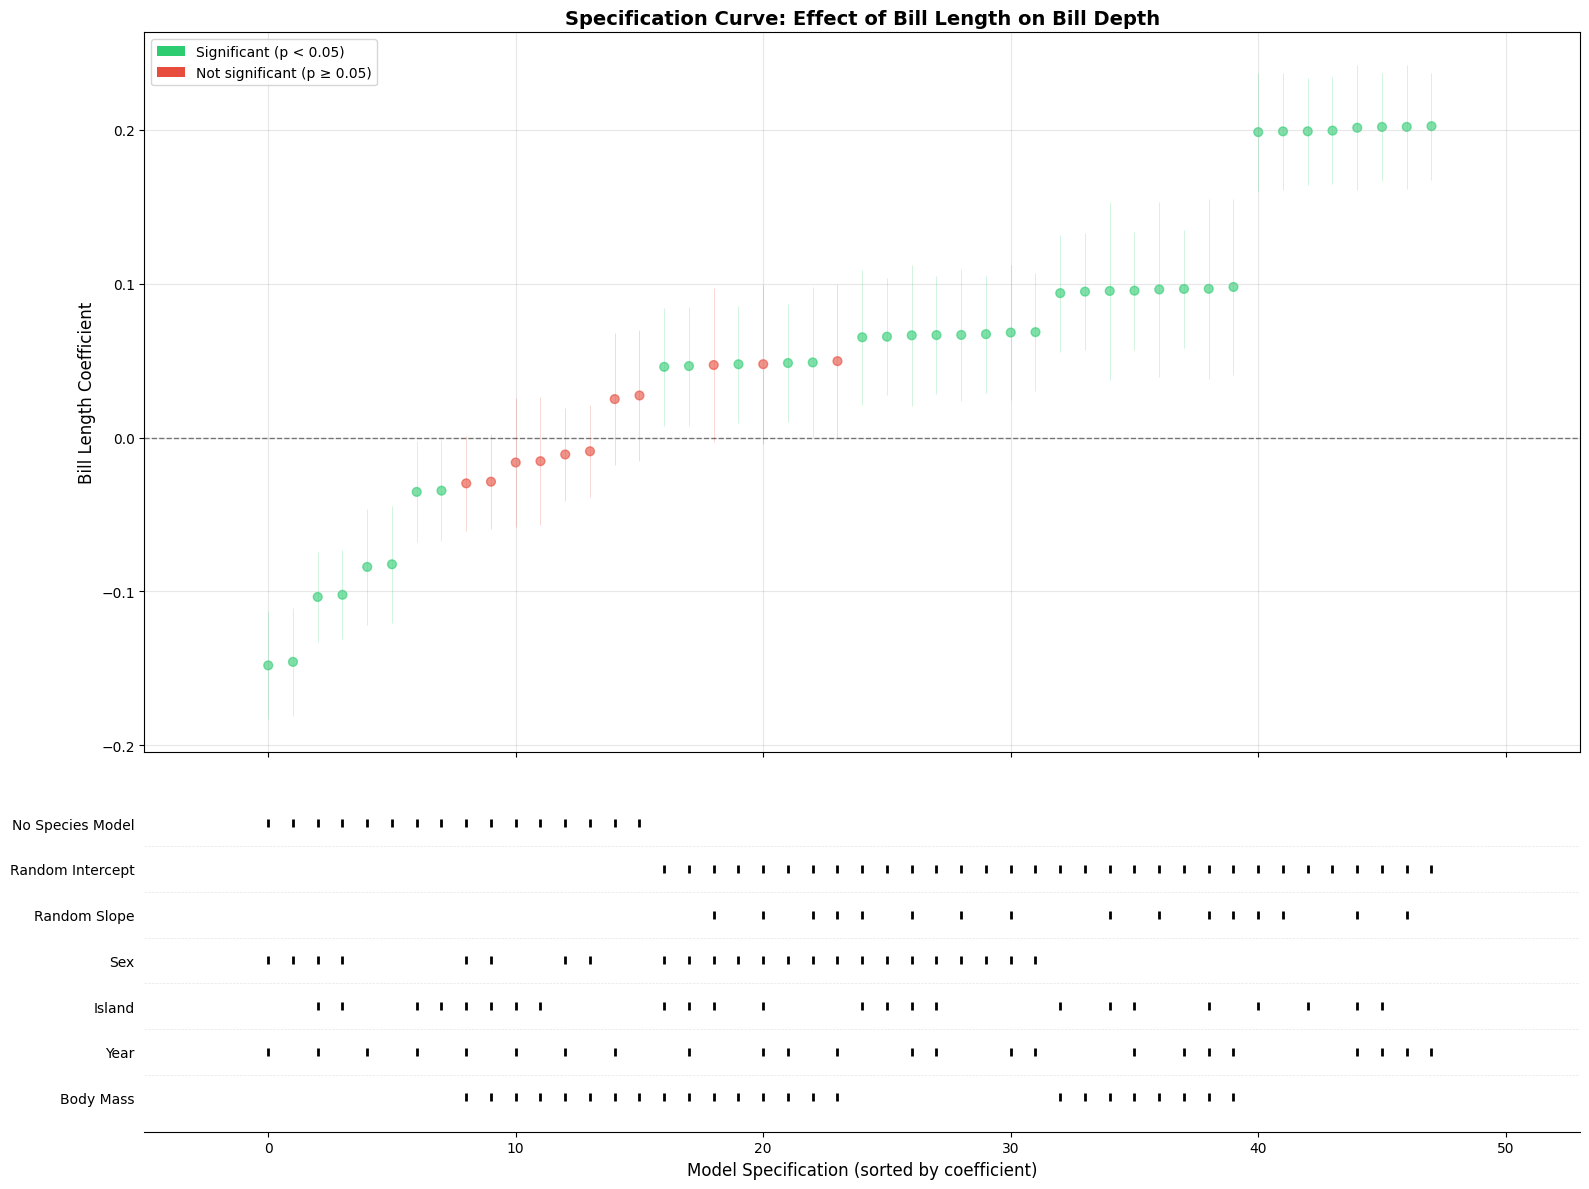


Coefficient range: [-0.1480, 0.2024]
Significant models (p < 0.05): 37 / 48 (77.1%)
All p-values < 0.05: False


In [9]:
# Specification curve: coefficients with confidence intervals
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True, 
                          gridspec_kw={'height_ratios': [2, 1]})

# Sort by coefficient value
results_df_sorted = results_df.sort_values('coefficient').reset_index(drop=True)
results_df_sorted['model_index'] = range(len(results_df_sorted))

# Parse covariates for each model
for cov in ['sex', 'island', 'year', 'body_mass']:
    results_df_sorted[f'has_{cov}'] = results_df_sorted['covariates'].apply(
        lambda x: cov in x if x != 'none' else False
    )

# Parse species model types
results_df_sorted['has_no_species'] = results_df_sorted['species_model'] == 'none'
results_df_sorted['has_random_intercept'] = results_df_sorted['species_model'].isin(['random_intercept', 'random_slope'])
results_df_sorted['has_random_slope'] = results_df_sorted['species_model'] == 'random_slope'

# Determine statistical significance (p < 0.05)
results_df_sorted['significant'] = results_df_sorted['p_value'] < 0.05

# Top panel: Coefficients with confidence intervals
ax1 = axes[0]

# Color code by significance
colors = results_df_sorted['significant'].map({True: '#2ecc71', False: '#e74c3c'})
ax1.scatter(results_df_sorted['model_index'], results_df_sorted['coefficient'], 
           alpha=0.6, s=40, c=colors)

# Also color the confidence interval lines
for idx, row in results_df_sorted.iterrows():
    color = '#2ecc71' if row['significant'] else '#e74c3c'
    ax1.vlines(row['model_index'], row['ci_lower'], row['ci_upper'],
              alpha=0.3, colors=color, linewidth=0.5)

ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1)
ax1.set_ylabel('Bill Length Coefficient', fontsize=12)
ax1.set_title('Specification Curve: Effect of Bill Length on Bill Depth', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add legend for significance
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Significant (p < 0.05)'),
    Patch(facecolor='#e74c3c', label='Not significant (p ≥ 0.05)')
]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=10)

# Bottom panel: Model specifications with tick marks
ax2 = axes[1]

# Define specification dimensions and their positions
spec_dimensions = [
    ('No Species Model', 'has_no_species'),
    ('Random Intercept', 'has_random_intercept'),
    ('Random Slope', 'has_random_slope'),
    ('Sex', 'has_sex'),
    ('Island', 'has_island'),
    ('Year', 'has_year'),
    ('Body Mass', 'has_body_mass')
]

# Plot each specification dimension
y_positions = np.linspace(0.85, 0.05, len(spec_dimensions))

for (label, column), y_pos in zip(spec_dimensions, y_positions):
    for idx, row in results_df_sorted.iterrows():
        x = row['model_index']
        # Show tick mark if feature is included
        if row[column]:
            ax2.scatter(x, y_pos, c='black', s=40, marker='|', linewidths=2)

# Set up y-axis labels
ax2.set_yticks(y_positions)
ax2.set_yticklabels([label for label, _ in spec_dimensions], fontsize=10)
ax2.set_ylim(-0.05, 1)
ax2.set_xlabel('Model Specification (sorted by coefficient)', fontsize=12)
ax2.set_xlim(-5, len(results_df_sorted) + 5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.tick_params(left=False)

# Add grid lines between specifications
for i in range(len(y_positions) - 1):
    y_mid = (y_positions[i] + y_positions[i + 1]) / 2
    ax2.axhline(y=y_mid, color='gray', linestyle='--', alpha=0.2, linewidth=0.5)

plt.tight_layout()
save_fig(fig, 'multiverse', CHAPTER, basedir=IMAGE_DIR)


plt.show()

print(f"\nCoefficient range: [{results_df['coefficient'].min():.4f}, {results_df['coefficient'].max():.4f}]")
print(f"Significant models (p < 0.05): {(results_df['p_value'] < 0.05).sum()} / {len(results_df)} ({100*(results_df['p_value'] < 0.05).mean():.1f}%)")
print(f"All p-values < 0.05: {(results_df['p_value'] < 0.05).all()}")

/var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/ipykernel_51682/1850391332.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot([group for name, group in species_grouped],
/var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/ipykernel_51682/1850391332.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot([group for name, group in cov_grouped],


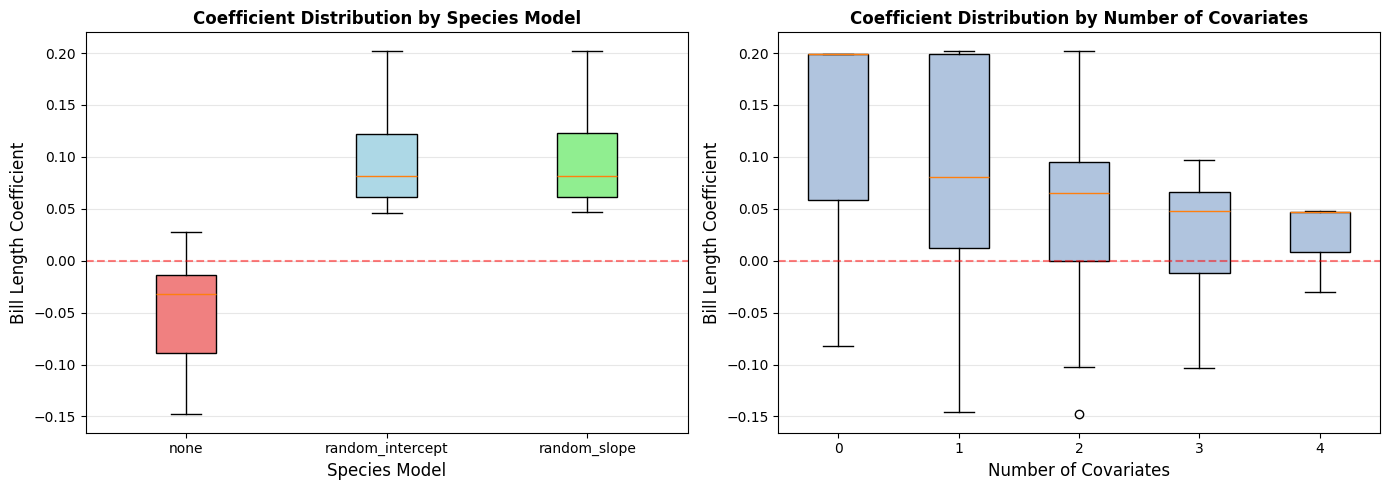

In [10]:
# Compare results across different modeling choices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By species model
ax1 = axes[0]
species_grouped = results_df.groupby('species_model')['coefficient']
positions = range(len(species_grouped))
bp1 = ax1.boxplot([group for name, group in species_grouped], 
                   labels=species_grouped.groups.keys(),
                   patch_artist=True)
for patch, color in zip(bp1['boxes'], ['lightcoral', 'lightblue', 'lightgreen']):
    patch.set_facecolor(color)
ax1.set_ylabel('Bill Length Coefficient', fontsize=12)
ax1.set_xlabel('Species Model', fontsize=12)
ax1.set_title('Coefficient Distribution by Species Model', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)

# By number of covariates
ax2 = axes[1]
results_df['n_covariates'] = results_df['covariates'].apply(
    lambda x: 0 if x == 'none' else len(x.split(','))
)
cov_grouped = results_df.groupby('n_covariates')['coefficient']
bp2 = ax2.boxplot([group for name, group in cov_grouped],
                   labels=[f'{int(name)}' for name in cov_grouped.groups.keys()],
                   patch_artist=True)
for patch in bp2['boxes']:
    patch.set_facecolor('lightsteelblue')
ax2.set_ylabel('Bill Length Coefficient', fontsize=12)
ax2.set_xlabel('Number of Covariates', fontsize=12)
ax2.set_title('Coefficient Distribution by Number of Covariates', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Exploratory visualization: Bill depth vs length relationships

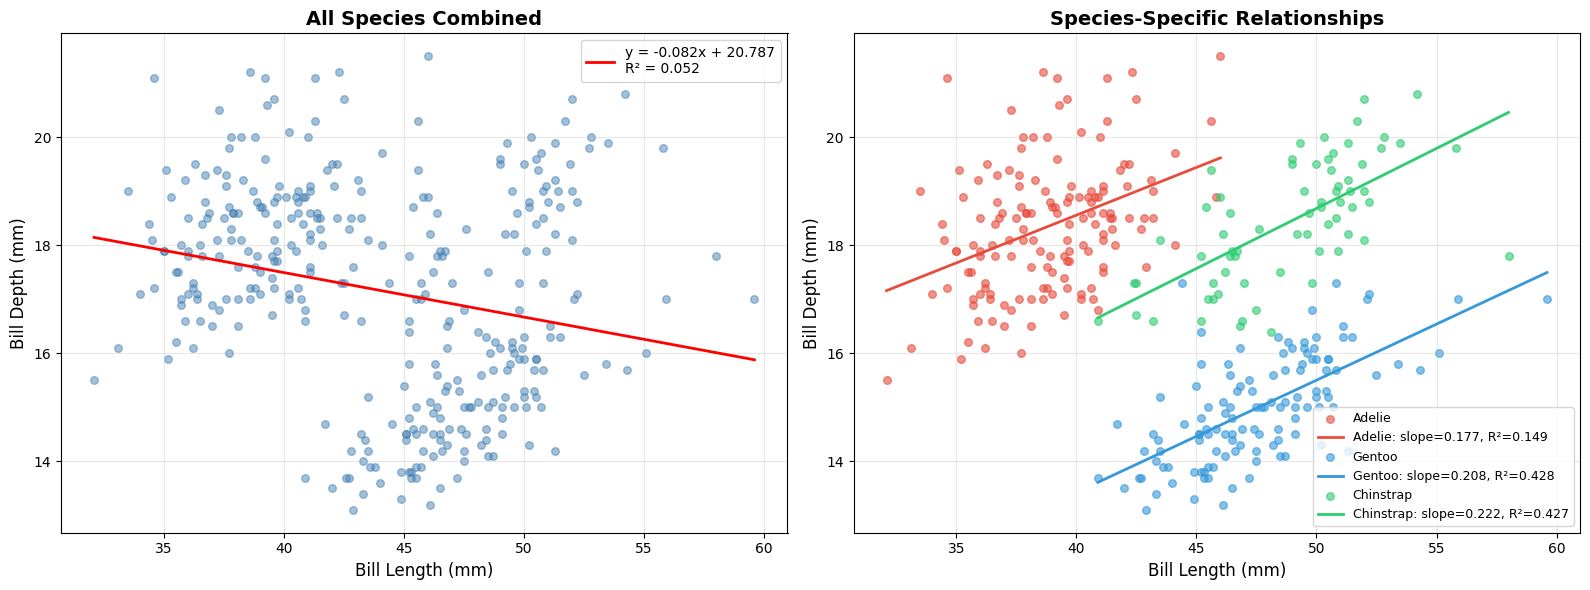


Regression Results:

All Species Combined:
  Slope: -0.0823 (SE: 0.0193)
  Intercept: 20.7866
  R²: 0.0523
  p-value: 2.53e-05
  N: 333

By Species:

  Adelie:
    Slope: 0.1767 (SE: 0.0352)
    Intercept: 11.4877
    R²: 0.1489
    p-value: 1.51e-06
    N: 146

  Gentoo:
    Slope: 0.2076 (SE: 0.0222)
    Intercept: 5.1210
    R²: 0.4277
    p-value: 7.34e-16
    N: 119

  Chinstrap:
    Slope: 0.2222 (SE: 0.0317)
    Intercept: 7.5691
    R²: 0.4271
    p-value: 1.53e-09
    N: 68


In [11]:
import numpy as np
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: All data together
ax1 = axes[0]
ax1.scatter(all_penguins['Culmen_Length'], all_penguins['Culmen_Depth'], 
           alpha=0.5, s=30, color='steelblue')

# Fit regression line for all data
mask = all_penguins[['Culmen_Length', 'Culmen_Depth']].notna().all(axis=1)
x_all = all_penguins.loc[mask, 'Culmen_Length']
y_all = all_penguins.loc[mask, 'Culmen_Depth']
slope, intercept, r_value, p_value, std_err = stats.linregress(x_all, y_all)

# Plot regression line
x_range = np.linspace(x_all.min(), x_all.max(), 100)
y_pred = slope * x_range + intercept
ax1.plot(x_range, y_pred, 'r-', linewidth=2, 
         label=f'y = {slope:.3f}x + {intercept:.3f}\nR² = {r_value**2:.3f}')

ax1.set_xlabel('Bill Length (mm)', fontsize=12)
ax1.set_ylabel('Bill Depth (mm)', fontsize=12)
ax1.set_title('All Species Combined', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right panel: Separate by species
ax2 = axes[1]

# Map actual species names to colors and short names
species_mapping = {
    'Adelie Penguin (Pygoscelis adeliae)': ('Adelie', '#e74c3c'),
    'Gentoo penguin (Pygoscelis papua)': ('Gentoo', '#3498db'),
    'Chinstrap penguin (Pygoscelis antarctica)': ('Chinstrap', '#2ecc71')
}

for species_full, (species_short, color) in species_mapping.items():
    species_data = all_penguins[all_penguins['Species'] == species_full]
    
    # Plot scatter
    ax2.scatter(species_data['Culmen_Length'], species_data['Culmen_Depth'],
               alpha=0.6, s=30, color=color, label=species_short)
    
    # Fit and plot regression line
    mask = species_data[['Culmen_Length', 'Culmen_Depth']].notna().all(axis=1)
    if mask.sum() > 2:  # Need at least 2 points for regression
        x_species = species_data.loc[mask, 'Culmen_Length']
        y_species = species_data.loc[mask, 'Culmen_Depth']
        slope, intercept, r_value, _, _ = stats.linregress(x_species, y_species)
        
        x_range = np.linspace(x_species.min(), x_species.max(), 50)
        y_pred = slope * x_range + intercept
        ax2.plot(x_range, y_pred, '-', linewidth=2, color=color,
                label=f'{species_short}: slope={slope:.3f}, R²={r_value**2:.3f}')

ax2.set_xlabel('Bill Length (mm)', fontsize=12)
ax2.set_ylabel('Bill Depth (mm)', fontsize=12)
ax2.set_title('Species-Specific Relationships', fontsize=14, fontweight='bold')
ax2.legend(fontsize=9, loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, 'simpsons-penguin', CHAPTER, basedir=IMAGE_DIR)


plt.show()

print("\nRegression Results:")
print("="*60)
print("\nAll Species Combined:")
mask = all_penguins[['Culmen_Length', 'Culmen_Depth']].notna().all(axis=1)
x_all = all_penguins.loc[mask, 'Culmen_Length']
y_all = all_penguins.loc[mask, 'Culmen_Depth']
slope, intercept, r_value, p_value, std_err = stats.linregress(x_all, y_all)
print(f"  Slope: {slope:.4f} (SE: {std_err:.4f})")
print(f"  Intercept: {intercept:.4f}")
print(f"  R²: {r_value**2:.4f}")
print(f"  p-value: {p_value:.2e}")
print(f"  N: {len(x_all)}")

print("\nBy Species:")
for species_full, (species_short, _) in species_mapping.items():
    species_data = all_penguins[all_penguins['Species'] == species_full]
    mask = species_data[['Culmen_Length', 'Culmen_Depth']].notna().all(axis=1)
    if mask.sum() > 2:
        x_species = species_data.loc[mask, 'Culmen_Length']
        y_species = species_data.loc[mask, 'Culmen_Depth']
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_species, y_species)
        print(f"\n  {species_short}:")
        print(f"    Slope: {slope:.4f} (SE: {std_err:.4f})")
        print(f"    Intercept: {intercept:.4f}")
        print(f"    R²: {r_value**2:.4f}")
        print(f"    p-value: {p_value:.2e}")
        print(f"    N: {len(x_species)}")